# G1 live SLAM point-cloud map viewer (eth0)

This notebook uses `sdk_wrapper.G1` on `eth0`, not `sdk_client`. It reads the wrapper's SLAM point-cloud subscriptions (`rt/unitree/slam_mapping/points`, relocation points, and global-map topics) and dynamically plots the map while G1 moves.

It is read-only unless you explicitly enable the optional mapping-start cell.

In [1]:
from pathlib import Path
import sys

# This notebook lives in academy/visualizations; sdk_wrapper.py lives in academy/.
ACADEMY = (Path.cwd().resolve() / '..').resolve()
if not (ACADEMY / 'sdk_wrapper.py').exists():
    raise FileNotFoundError('Cannot find sdk_wrapper.py under ' + str(ACADEMY))
if str(ACADEMY) not in sys.path:
    sys.path.insert(0, str(ACADEMY))

from sdk_wrapper import G1

IFACE = 'eth0'
DOMAIN_ID = 0
g1 = G1(iface=IFACE, domain_id=DOMAIN_ID)
print(f'Connected sdk_wrapper.G1 on iface={g1.iface!r}, domain_id={g1.domain_id}')

Connected sdk_wrapper.G1 on iface='eth0', domain_id=0


In [2]:
import time

# Let the wrapper's DDS subscribers receive data, then inspect the exact SLAM topic.
time.sleep(1.0)
latest = g1._latest_cloud_msg()  # wrapper diagnostic: (topic, message, receive_time)
print('SLAM pose (x, y, yaw):', g1.get_slam_pose())
print('Latest SLAM cloud:', None if latest is None else (latest[0], time.ctime(latest[2])))
print('Latest SLAM point count:', len(g1.get_point_cloud()))
print('SLAM notice:', g1.get_slam_notice())

# Mapping must be running before the SLAM point topics publish. Leave this False
# if mapping is started elsewhere. Set it True only to start mapping from this kernel.
START_MAPPING_HERE = False
if START_MAPPING_HERE:
    print(g1.start_mapping(slam_type='indoor'))

SLAM pose (x, y, yaw): None
Latest SLAM cloud: ('rt/unitree/slam_mapping/points', 'Wed Oct  7 16:09:49 2026')
Latest SLAM point count: 1330
SLAM notice: {'type': 'ctrl_info', 'error_code': 0, 'info': 'not init', 'is_arrived': False, 'target_node_name': 0, 'obstacle_blocked': False, 'stamp': 1791382189.431202}


In [3]:
import numpy as np
import plotly.graph_objects as go
from IPython.display import display

def slam_points_xyz(max_points=20000, z_min=-1.0, z_max=1.5):
    """Read the current map cloud through sdk_wrapper.G1.get_point_cloud()."""
    raw = g1.get_point_cloud()
    if not raw:
        return np.empty((0, 3), dtype=np.float32)
    pts = np.asarray([(p['x'], p['y'], p['z']) for p in raw], dtype=np.float32)
    pts = pts[np.isfinite(pts).all(axis=1) & (pts[:, 2] >= z_min) & (pts[:, 2] <= z_max)]
    if len(pts) > max_points:
        pts = pts[np.linspace(0, len(pts) - 1, max_points, dtype=np.int64)]
    return pts

def cloud_status():
    latest = g1._latest_cloud_msg()
    if latest is None:
        return 'waiting for a SLAM point-cloud message'
    topic, _msg, stamp = latest
    return f'{topic} | message age {time.time() - stamp:.1f}s'

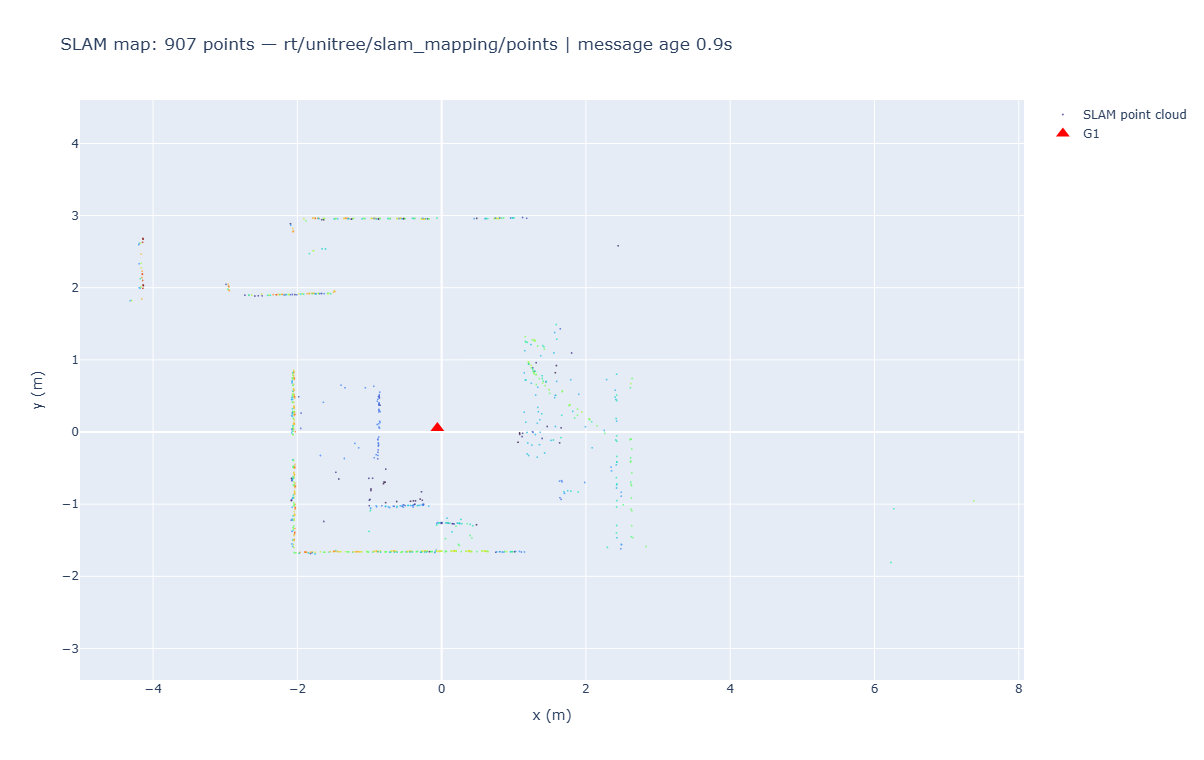

In [4]:
# Static check: run this after mapping is running.
pts = slam_points_xyz()
fig = go.Figure()
if len(pts):
    fig.add_trace(go.Scattergl(x=pts[:, 0], y=pts[:, 1], mode='markers',
                               marker=dict(size=2, color=pts[:, 2], colorscale='Turbo', opacity=0.75),
                               name='SLAM point cloud'))
pose = g1.get_slam_pose()
if pose is not None:
    fig.add_trace(go.Scatter(x=[pose[0]], y=[pose[1]], mode='markers',
                             marker=dict(size=12, color='red', symbol='triangle-up'), name='G1'))
fig.update_layout(title=f'SLAM map: {len(pts):,} points — {cloud_status()}',
                  xaxis_title='x (m)', yaxis_title='y (m)', yaxis_scaleanchor='x', width=900, height=760)
fig.show()

In [ ]:
def live_slam_map(duration_s=120, refresh_s=0.5, max_points=20000):
    """Continuously redraw the newest SLAM map cloud from sdk_wrapper.

    Unlike the previous raw-LiDAR version, this reads `G1.get_point_cloud()`
    each update. It therefore works when mapping is started in a separate terminal.
    Interrupt this cell to stop the viewer.
    """
    fig = go.FigureWidget()
    fig.add_scattergl(x=[], y=[], mode='markers', marker=dict(size=2, color='#d9d9d9', opacity=0.70), name='SLAM map')
    fig.add_scatter(x=[], y=[], mode='lines', line=dict(color='#ffb000', width=2), name='SLAM path')
    fig.add_scatter(x=[], y=[], mode='markers', marker=dict(size=12, color='red', symbol='triangle-up'), name='G1')
    fig.update_layout(xaxis_title='x (m)', yaxis_title='y (m)', yaxis_scaleanchor='x', width=900, height=760, title='Waiting for SLAM point-cloud messages…')
    display(fig)

    path = []
    started = time.monotonic()
    try:
        while time.monotonic() - started < duration_s:
            pts = slam_points_xyz(max_points=max_points)
            pose = g1.get_slam_pose()
            if pose is not None:
                path.append((pose[0], pose[1]))
                path = path[-3000:]
            with fig.batch_update():
                fig.data[0].x = pts[:, 0] if len(pts) else []
                fig.data[0].y = pts[:, 1] if len(pts) else []
                fig.data[1].x = [p[0] for p in path]
                fig.data[1].y = [p[1] for p in path]
                fig.data[2].x = [] if pose is None else [pose[0]]
                fig.data[2].y = [] if pose is None else [pose[1]]
                fig.layout.title = f'Live SLAM map | {len(pts):,} points | {cloud_status()}'
            time.sleep(refresh_s)
    except KeyboardInterrupt:
        print('Live viewer stopped.')

live_slam_map(duration_s=120, refresh_s=0.5)

If the viewer says `waiting for a SLAM point-cloud message`, start mapping, move G1 a short distance, and rerun only the live-view cell—do not reload the kernel. The title shows the exact selected topic and its message age. If its age rises continuously, mapping is no longer publishing; if points stay zero while the age is fresh, inspect the selected topic with `ros2 topic echo` in another terminal.